# **Présentation de CC3**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,  LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## importez student-mat.csv

In [ ]:
df = pd.read_csv('/content/student-mat.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Les valeurs manquantes

In [ ]:
df.isnull().sum()


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


### Les valeurs duplicates

In [ ]:
df = df.drop_duplicates()
df = df.dropna()

## Drop columns

In [ ]:
df = df.drop(["school", "Mjob", "Fjob", "reason", "guardian"], axis=1)

## Analyse Exploratoire

In [ ]:
print(df.groupby("studytime")["G3"].mean())
print(df.groupby("failures")["G3"].mean())
print(df.groupby("sex")["G3"].mean())

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64
failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


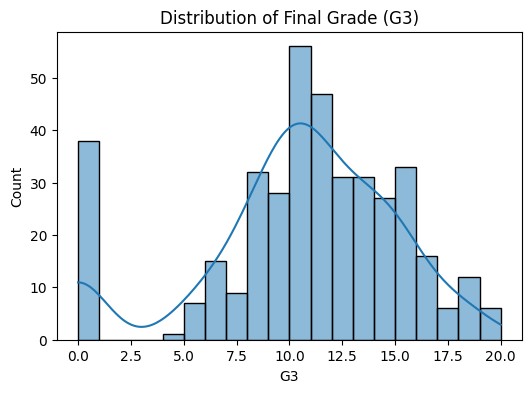

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.show()
#La distribution des notes est globalement équilibrée.
#La majorité des étudiants ont des notes moyennes.

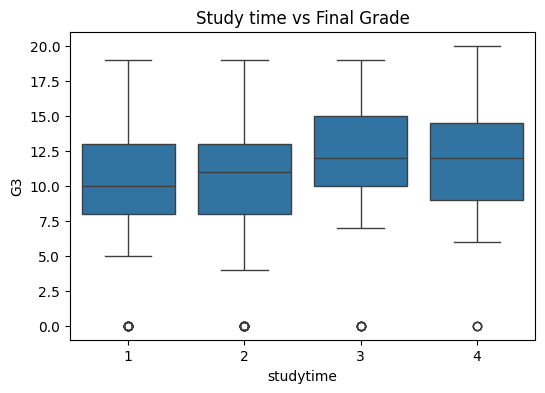

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="studytime", y="G3", data=df)
plt.title("Study time vs Final Grade")
plt.show()
# plus le temps d’étude augmente, plus la note finale G3 augmente

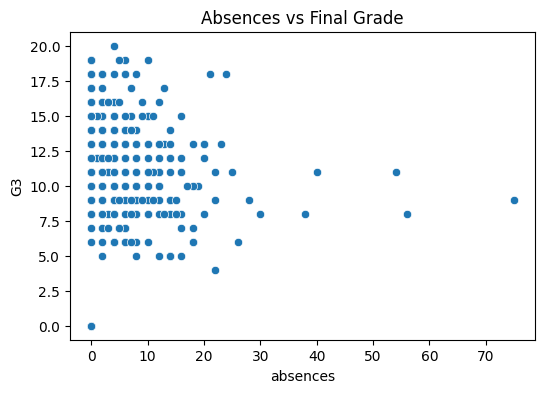

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="absences", y="G3", data=df)
plt.title("Absences vs Final Grade")
plt.show()
# tendance négative : plus les absences augmentent, plus la note diminue

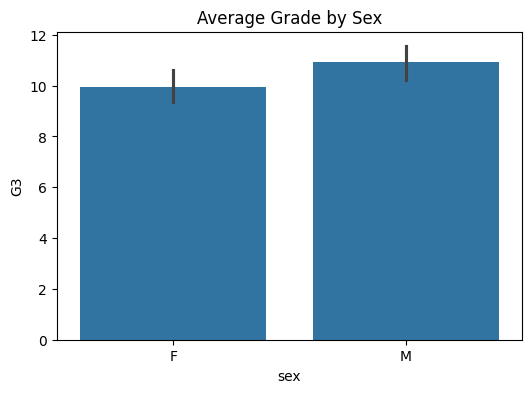

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="G3", data=df)
plt.title("Average Grade by Sex")
plt.show()

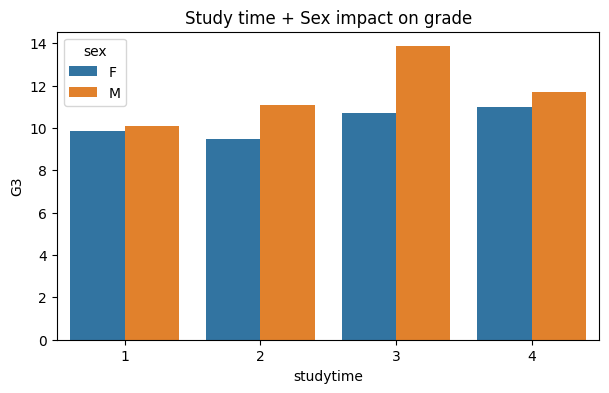

In [ ]:
df_group = df.groupby(["sex","studytime"])["G3"].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(x="studytime", y="G3", hue="sex", data=df_group)
plt.title("Study time + Sex impact on grade")
plt.show()
#Le temps d’étude influence positivement la performance des étudiants, indépendamment du sexe.
#Le sexe n’a pas un impact significatif comparé au temps d’étude.

### Feature Engineering

In [ ]:
# la somme des note G1 et G2
df["G_avg"] = (df["G1"] + df["G2"]) / 2

# Conversion de certaines colonnes en variables numériques
binary_cols = ["schoolsup", "famsup", "paid", "activities", "internet", "romantic"]

for col in binary_cols:
    df[col] = df[col].map({"yes":1, "no":0})

# sex
df["sex"] = df["sex"].map({"M":1, "F":0})

# address
df["address"] = df["address"].map({"U":1, "R":0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop(["G3","G1", "G2"], axis=1)
y = df["G3"]

## Mettez les features dans X et target Dans y

## Diviser les données en train et test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Normalisation

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Gradient Boosting

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

### Prédiction et Évaluation

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.149113924050633
RMSE: 1.8499928155864604
R2: 0.833091171506267


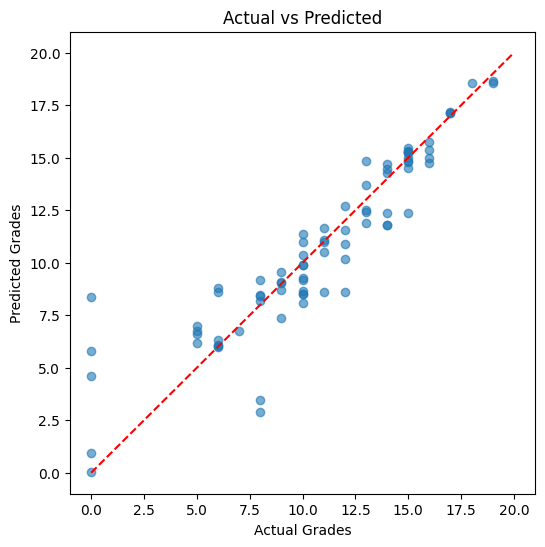

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted")
plt.plot([0,20],[0,20],'r--')
plt.show()

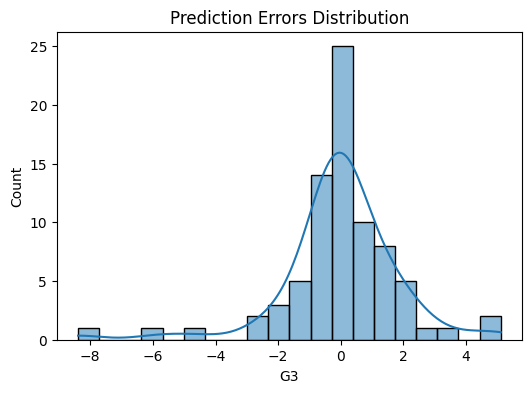

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Errors Distribution")
plt.show()